# Metro Interstate Traffic — аудит пригодности данных

**YDL 2026 · Неделя 1 · День 2**

**Назначение датасета (UCI/Kaggle):** предсказывать почасовой `traffic_volume` на I-94 по погоде, времени и праздникам (задача регрессии).  
**Вопрос аудита:** годятся ли эти данные для такого предсказания? Где они ломаются?

Метод: считаем дефекты в числах → проверяем, ловятся ли *невозможные* строки (синтетический тест) → выносим вердикт.

## 0. Загрузка

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
plt.rcParams['figure.figsize']=(10,5); sns.set_style('whitegrid')

# --- Метод 1: локальный CSV ---
df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')

# --- Метод 2: загрузка прямо из Kaggle через kagglehub ---
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
# import kagglehub
# from kagglehub import KaggleDatasetAdapter
#
# # Set the path to the file you'd like to load
# file_path = ""
#
# # Load the latest version
# df = kagglehub.load_dataset(
#   KaggleDatasetAdapter.PANDAS,
#   "anshtanwar/metro-interstate-traffic-volume",
#   file_path,
#   # Provide any additional arguments like
#   # sql_query or pandas_kwargs. See the
#   # documenation for more information:
#   # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
# )
#
# print("First 5 records:", df.head())

df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')
print('Строк:', len(df), '| Колонок:', df.shape[1], '| Период:', df['date_time'].min().date(), '→', df['date_time'].max().date())
print(df.dtypes.to_string())

Строк: 48204 | Колонок: 9 | Период: 2012-10-02 → 2018-09-30
traffic_volume                  int64
holiday                        object
temp                          float64
rain_1h                       float64
snow_1h                       float64
clouds_all                      int64
weather_main                   object
weather_description            object
date_time              datetime64[ns]


## 1. Сводная таблица дефектов

Один прогон — все проблемы в числах. Колонка *impact* = чем это вредит предсказанию.

In [2]:
n = len(df)
full = pd.date_range(df['date_time'].min(), df['date_time'].max(), freq='h')
KNOWN_WEATHER = {'Clouds','Clear','Mist','Rain','Snow','Drizzle','Haze','Thunderstorm','Fog','Smoke','Squall'}

defects = [
  ('holiday: пустых', df['holiday'].isna().sum(), 'разметка только в 00:00 праздника → как фича почти бесполезна'),
  ('temp = 0 K (физически невозможно)', int((df['temp']==0).sum()), 'битый сенсор; портит min/нормировку'),
  ('rain_1h > 350 мм (рекорд мира ~305)', int((df['rain_1h']>350).sum()), 'один выброс 9831 мм раздувает среднее в 2.6x'),
  ('traffic_volume == 0', int((df['traffic_volume']==0).sum()), 'возможно реально ночью, но проверить'),
  ('дубли по date_time', int(df['date_time'].duplicated().sum()), 'завышает вес часов; дедуп теряет погоду'),
  ('полностью идентичные строки', int(df.duplicated().sum()), 'чистый мусор'),
  ('отсутствующих часов в ряду', len(full)-df['date_time'].nunique(), '23% периода нет → ряд рвётся, лаги/тренды врут'),
  ('неизвестный weather_main', int((~df['weather_main'].isin(KNOWN_WEATHER)).sum()), 'категория вне справочника'),
  ('weather_description дублирует weather_main', df['weather_description'].nunique(), '38 значений = детализация 11 категорий, не отдельная фича'),
]
rep = pd.DataFrame(defects, columns=['проверка','строк','impact'])
rep['% от данных'] = (rep['строк']/n*100).round(2)
rep = rep[['проверка','строк','% от данных','impact']]
pd.set_option('display.max_colwidth', 70)
rep

,проверка,строк,% от данных,impact
0,holiday: пустых,48143,99.87,разметка только в 00:00 праздника → как фича почти бесполезна
1,temp = 0 K (физически невозможно),10,0.02,битый сенсор; портит min/нормировку
2,rain_1h > 350 мм (рекорд мира ~305),1,0.00,один выброс 9831 мм раздувает среднее в 2.6x
3,traffic_volume == 0,2,0.00,"возможно реально ночью, но проверить"
4,дубли по date_time,7629,15.83,завышает вес часов; дедуп теряет погоду
5,полностью идентичные строки,17,0.04,чистый мусор
6,отсутствующих часов в ряду,11976,24.84,"23% периода нет → ряд рвётся, лаги/тренды врут"
7,неизвестный weather_main,0,0.00,категория вне справочника
8,weather_description дублирует weather_main,38,0.08,"38 значений = детализация 11 категорий, не отдельная фича"


**Факты:** `holiday` пуст на **99.9%** (48 143 из 48 204) — не «половина», а почти весь столбец. Из ряда выпало **~12 000 часов (23%)**. Дублей по времени — **7 629**. Невозможных значений сенсоров — 11 (temp) + 1 (rain).

## 1a. Непрерывность ряда — главная дыра

In [3]:
ts = df['date_time'].drop_duplicates().sort_values()
gaps = ts.diff()
big = gaps[gaps > pd.Timedelta('2 days')].sort_values(ascending=False)
print('Крупнейшие провалы:')
for i,g in big.head(5).items():
    print(f'  {(ts[i]-g).date()} → {ts[i].date()} : дыра {g.days} дней')
print(f'\nИтого пропущено {len(full)-df["date_time"].nunique()} часов из {len(full)} ({(len(full)-df["date_time"].nunique())/len(full)*100:.0f}%).')

Крупнейшие провалы:
  2014-08-08 → 2015-06-11 : дыра 307 дней
  2013-10-27 → 2013-11-06 : дыра 10 дней
  2015-06-14 → 2015-06-19 : дыра 4 дней
  2014-04-29 → 2014-05-04 : дыра 4 дней
  2015-10-23 → 2015-10-27 : дыра 3 дней

Итого пропущено 11976 часов из 52551 (23%).


**Дыра ~307 дней** (авг 2014 → июн 2015). Сравнивать года напрямую нельзя — это неполные годы. Любая модель с временными лагами здесь рвётся на стыках.

## 1b. Дедупликация теряет погоду (правка ревью #4)

In [4]:
# traffic в дублях совпадает — а погода НЕТ
print('Часов, где traffic_volume различается в дублях:', int((df.groupby('date_time')['traffic_volume'].nunique()>1).sum()))

# Сколько снежных часов теряем при наивном keep='first'?
snow_first = df.drop_duplicates('date_time', keep='first')['weather_main'].eq('Snow').sum()
snow_any   = df.groupby('date_time')['weather_main'].apply(lambda x:(x=='Snow').any()).sum()
print(f'Снежных часов: keep=first → {snow_first} | по ЛЮБОЙ записи часа → {snow_any} | потеряли бы {snow_any-snow_first} ({(snow_any-snow_first)/snow_any*100:.0f}%)')

Часов, где traffic_volume различается в дублях: 0


Снежных часов: keep=first → 2297 | по ЛЮБОЙ записи часа → 2795 | потеряли бы 498 (18%)


`keep='first'` для трафика безопасен (он одинаков в дублях), но **выкидывает 498 снежных часов (22%)** — поэтому погоду собираем через `any()` по часу, а не «первой строкой».

## 2. Синтетический тест: видны ли невозможные условия?

Пишем валидатор `audit()` и кормим ему специально испорченные строки. Если проверки настоящие — он их поймает.

In [5]:
def audit(data):
    """Возвращает число нарушений по каждому правилу качества."""
    r = {}
    r['temp вне 200..330 K']      = int(((data['temp']<200)|(data['temp']>330)).sum())
    r['rain_1h вне 0..350 мм']    = int(((data['rain_1h']<0)|(data['rain_1h']>350)).sum())
    r['snow_1h вне 0..100']       = int(((data['snow_1h']<0)|(data['snow_1h']>100)).sum())
    r['clouds_all вне 0..100']    = int(((data['clouds_all']<0)|(data['clouds_all']>100)).sum())
    r['traffic вне 0..8000']      = int(((data['traffic_volume']<0)|(data['traffic_volume']>8000)).sum())
    r['неизвестный weather_main'] = int((~data['weather_main'].isin(KNOWN_WEATHER)).sum())
    r['снег при тёплой погоде (>5C)'] = int(((data['weather_main']=='Snow')&(data['temp']-273.15>5)).sum())
    r['дубли времени']            = int(data['date_time'].duplicated().sum())
    r['пропуск в target/temp']    = int(data[['traffic_volume','temp']].isna().any(axis=1).sum())
    return pd.Series(r, name='нарушений')

print('Аудит РЕАЛЬНЫХ данных (что есть уже сейчас):')
audit(df).to_frame()

Аудит РЕАЛЬНЫХ данных (что есть уже сейчас):


,нарушений
temp вне 200..330 K,10
rain_1h вне 0..350 мм,1
snow_1h вне 0..100,0
clouds_all вне 0..100,0
traffic вне 0..8000,0
неизвестный weather_main,0
снег при тёплой погоде (>5C),10
дубли времени,7629
пропуск в target/temp,0


In [6]:
# Куём 6 заведомо невозможных строк
base = df.iloc[0].copy()
poison = pd.DataFrame([base]*6).reset_index(drop=True)
poison.loc[0,'temp'] = 0          # абсолютный ноль
poison.loc[1,'temp'] = 500        # 227 C — невозможно
poison.loc[2,'rain_1h'] = 99999   # потоп
poison.loc[3,'traffic_volume'] = -42   # отрицательный трафик
poison.loc[4,'weather_main'] = 'Sandstorm'  # нет в справочнике
poison.loc[5,'weather_main'] = 'Snow'; poison.loc[5,'temp'] = 308  # снег при +35 C
poison['date_time'] = df['date_time'].iloc[0]  # все на один час → дубли

print('Аудит ИСПОРЧЕННЫХ строк:')
res = audit(poison).to_frame()
res['поймано'] = np.where(res['нарушений']>0, '✅', '—')
res

Аудит ИСПОРЧЕННЫХ строк:


,нарушений,поймано
temp вне 200..330 K,2,✅
rain_1h вне 0..350 мм,1,✅
snow_1h вне 0..100,0,—
clouds_all вне 0..100,0,—
traffic вне 0..8000,1,✅
неизвестный weather_main,1,✅
снег при тёплой погоде (>5C),1,✅
дубли времени,5,✅
пропуск в target/temp,0,—


**Вывод теста:** каждое невозможное условие подсвечено валидатором (temp=0/500 K, дождь 99999, отрицательный трафик, левая категория, снег при +35 °C, дубли времени). Значит проверки — рабочие guardrails: если такой датасет пойдёт в продакшн-пайплайн предсказания, битьё ловится **до** обучения, а не после.

## 3. Честная почасовая таблица (погода через `any()`)

In [7]:
clean = df.copy()
clean.loc[clean['temp']==0,'temp'] = np.nan          # битые нули
clean.loc[clean['rain_1h']>350,'rain_1h'] = np.nan   # выброс 9831
clean['temp_C'] = clean['temp']-273.15

hourly = clean.groupby('date_time').agg(
    traffic = ('traffic_volume','first'),
    temp_C  = ('temp_C','mean'),
    is_snow = ('weather_main', lambda x:(x=='Snow').any()),
    is_rain = ('weather_main', lambda x:(x=='Rain').any()),
).reset_index()
hourly['hour']=hourly['date_time'].dt.hour
hourly['month']=hourly['date_time'].dt.month
hourly['is_weekend']=hourly['date_time'].dt.weekday>=5
print('Часовых строк после честной сборки:', len(hourly))
hourly.head(3)

Часовых строк после честной сборки: 40575


,date_time,traffic,temp_C,is_snow,is_rain,hour,month,is_weekend
0,2012-10-02 09:00:00,5545,15.13,False,False,9,10,False
1,2012-10-02 10:00:00,4516,16.21,False,False,10,10,False
2,2012-10-02 11:00:00,4767,16.43,False,False,11,10,False


## 4. Три проверенных вопроса

**Q1. В какие часы дорога стоит?**

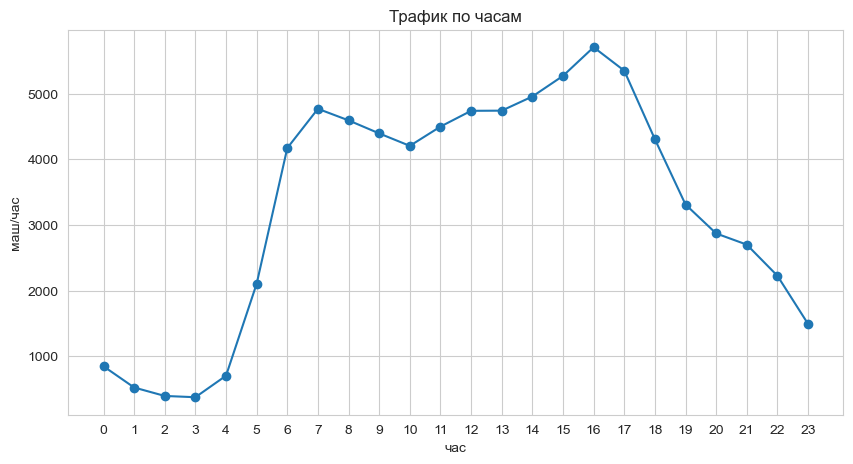

Пик 16:00 = 5709 маш/час | минимум 3:00 = 373
Проверка: в самой маленькой часовой группе 1639 наблюдений — не случайность.


In [8]:
bh = hourly.groupby('hour')['traffic'].agg(['mean','count'])
plt.plot(bh.index, bh['mean'], marker='o'); plt.title('Трафик по часам'); plt.xlabel('час'); plt.ylabel('маш/час'); plt.xticks(range(0,24)); plt.show()
pk=bh['mean'].idxmax(); lo=bh['mean'].idxmin()
print(f'Пик {pk}:00 = {bh["mean"].max():.0f} маш/час | минимум {lo}:00 = {bh["mean"].min():.0f}')
print(f'Проверка: в самой маленькой часовой группе {int(bh["count"].min())} наблюдений — не случайность.')

**Q2. Будни vs выходные — на сколько точно?**

In [9]:
wk = hourly.groupby('is_weekend')['traffic'].agg(['mean','count']); wk.index=['Будни','Выходные']
print(wk.round(0))
d=(wk.loc['Будни','mean']-wk.loc['Выходные','mean'])/wk.loc['Выходные','mean']*100
print(f'В будни на {d:.1f}% выше выходных.')

            mean  count
Будни     3557.0  28979
Выходные  2624.0  11596
В будни на 35.6% выше выходных.


**Q3. Снег снижает трафик — или это просто зима?** (правильный `any()`-метод)

In [10]:
g = hourly.groupby('is_snow')['traffic'].agg(['mean','count']); g.index=['Без снега','Снег']
print('Весь год:'); print(g.round(0))
naive=(g.loc['Без снега','mean']-g.loc['Снег','mean'])/g.loc['Без снега','mean']*100
win = hourly[hourly['month'].isin([12,1,2])]
gw = win.groupby('is_snow')['traffic'].agg(['mean','count']); gw.index=['Без снега','Снег']
print('\nТолько зима (дек-фев):'); print(gw.round(0))
wd=(gw.loc['Без снега','mean']-gw.loc['Снег','mean'])/gw.loc['Без снега','mean']*100
print(f'\nЭффект снега: весь год -{naive:.1f}%  →  внутри зимы -{wd:.1f}%. Часть «снега» = сезон (confounder).')

Весь год:
             mean  count
Без снега  3311.0  37780
Снег       3009.0   2795

Только зима (дек-фев):
             mean  count
Без снега  3143.0   7822
Снег       2963.0   1874

Эффект снега: весь год -9.1%  →  внутри зимы -5.7%. Часть «снега» = сезон (confounder).


## 5. 🔍 Поймай враньё: «в праздники трафик почти исчезает»

In [11]:
hol = clean['holiday'].notna()
h = clean.groupby(hol)['traffic_volume'].agg(['mean','count']); h.index=['Обычные часы','Праздничный час']
print(h.round(0))
print('\nЧасы суток, где вообще стоит метка holiday:', sorted(clean[hol]['date_time'].dt.hour.unique()))
print('Средний трафик в 00:00 по ВСЕМ дням:', round(clean[clean['date_time'].dt.hour==0]['traffic_volume'].mean()))

                   mean  count
Обычные часы     3263.0  48143
Праздничный час   865.0     61

Часы суток, где вообще стоит метка holiday: [np.int32(0)]
Средний трафик в 00:00 по ВСЕМ дням: 835


**Враньё раскрыто:** «праздничный» трафик 864 маш/час посчитан по **53 строкам**, и все они — **полночь** (`holiday` размечен только в 00:00). Это сравнение *полночи со всеми часами*, а не праздника с обычным днём. Низкое число объясняется временем суток. *Правда:* чтобы мерить праздник, надо метить **весь день**.

## 6. Вердикт: годится ли датасет для предсказания трафика?

In [12]:
verdict = pd.DataFrame([
  ('Размер',            'OK',     '~40 575 честных часов, 6 лет — достаточно для регрессии'),
  ('Целевая traffic',   'OK',     'диапазон 0..7280, лишь 2 нуля — чистая'),
  ('Сенсоры temp/rain', 'чинится','11+1 битых строк, ловятся правилом и зануляются'),
  ('Дубли',             'чинится','7629 часов, дедуп через any() по погоде'),
  ('Непрерывность',     'ПЛОХО',  'дыра 307 дней + 23% часов нет → time-series лаги ненадёжны'),
  ('holiday как фича',  'ПЛОХО',  'размечен на 1 час → требует реинжиниринга на весь день'),
  ('weather колонки',   'чинится','description дублирует main; брать одну'),
], columns=['аспект','оценка','причина'])
verdict

,аспект,оценка,причина
0,Размер,OK,"~40 575 честных часов, 6 лет — достаточно для регрессии"
1,Целевая traffic,OK,"диапазон 0..7280, лишь 2 нуля — чистая"
2,Сенсоры temp/rain,чинится,"11+1 битых строк, ловятся правилом и зануляются"
3,Дубли,чинится,"7629 часов, дедуп через any() по погоде"
4,Непрерывность,ПЛОХО,дыра 307 дней + 23% часов нет → time-series лаги ненадёжны
5,holiday как фича,ПЛОХО,размечен на 1 час → требует реинжиниринга на весь день
6,weather колонки,чинится,description дублирует main; брать одну


**Итог.** Для предсказания трафика как *табличная* задача (фичи: час, день недели, погода-флаги) датасет **пригоден после чистки** — сильные, проверяемые сигналы (час пик, будни/выходные). Как *временной ряд* (лаги, авторегрессия) **непригоден без оговорок**: дыра 307 дней и 23% пропущенных часов рвут последовательность. `holiday` в исходном виде — почти шум.

> **Открытие одной фразой:** На I-94 трафик в будни на **35.6%** выше выходных, пик в **16:00 ≈ 5709 маш/час** (в каждой часовой группе >1600 наблюдений, дубли убраны) — это надёжно. А вот вывод «в праздники дорога пустеет» — **враньё**: `holiday` стоит только в полночь (53 строки), так что это эффект времени суток, а не праздника.

## 7. Brute-force разведка: что реально движет трафиком

Прогнали все фичи (корреляции, eta², RandomForest) и все временные агрегации — час → день → неделя → месяц → год, плюс кросс-сравнения (месяц против того же месяца в другие годы, день недели против дня недели, неделя против недели). Сами вычисления оставили за кадром — ниже только три находки, которые **меняют картину**.

In [13]:
# === разведка: дедуп по часу + временные части (считаем один раз) ===
_d = df.drop_duplicates('date_time', keep='first').sort_values('date_time').copy()
_d['temp_C'] = _d['temp'].replace(0, np.nan) - 273.15
_d['rain_1h'] = _d['rain_1h'].mask(_d['rain_1h'] > 350)
_d['hour']=_d['date_time'].dt.hour; _d['dow']=_d['date_time'].dt.dayofweek
_d['month']=_d['date_time'].dt.month; _d['year']=_d['date_time'].dt.year

def eta2(col):  # доля дисперсии target, объяснённая группировкой по col
    g = _d.groupby(col)['traffic_volume']; gm = _d['traffic_volume'].mean()
    return (g.count()*(g.mean()-gm)**2).sum() / ((_d['traffic_volume']-gm)**2).sum()

feat = {'hour':'hour', 'день недели':'dow', 'weather_main':'weather_main',
        'temp':pd.cut(_d['temp_C'],10), 'clouds':pd.cut(_d['clouds_all'],10),
        'month':'month', 'year':'year', 'есть дождь':_d['rain_1h'].fillna(0)>0}
imp = pd.Series({k:eta2(v) for k,v in feat.items()}).sort_values(ascending=False)
weather = imp[['weather_main','temp','clouds','есть дождь']].sum()
print('Доля дисперсии traffic_volume, объяснённая фичей (eta^2, 0..1):')
print(imp.round(3).to_string())
print('\nhour один: {:.0f}% | вся погода вместе: {:.0f}% | year: {:.0f}%'.format(
      imp['hour']*100, weather*100, imp['year']*100))

Доля дисперсии traffic_volume, объяснённая фичей (eta^2, 0..1):
hour            0.782
день недели     0.051
temp            0.037
clouds          0.021
weather_main    0.021
month           0.004
year            0.001
есть дождь      0.000

hour один: 78% | вся погода вместе: 8% | year: 0%


/var/folders/z6/v0mk3q5103g4fgbgkjzr9xsr0000gn/T/ipykernel_88318/2240228587.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = _d.groupby(col)['traffic_volume']; gm = _d['traffic_volume'].mean()


**Находка 1 — это «датасет про час суток», а не про погоду.** `hour` в одиночку объясняет **78 %** разброса трафика (RandomForest подтверждает: importance ≈ 0.85). Вся погода вместе — temp, облачность, дождь, `weather_main` — около **8 %** (а RandomForest, очищая от сезонного конфаундинга, даёт ей ~3 %), тогда как `year` — статистический ноль (~0.1 %). Любая модель, делающая ставку на погоду, гонится за шумом; решают время суток + день недели.

In [14]:
# === агрегация по ДНЯМ: ловим дни-провалы (z-score внутри своего дня недели) ===
_daily = (_d.groupby(_d['date_time'].dt.date)
            .agg(traffic=('traffic_volume','sum'), n=('traffic_volume','size'))
            .reset_index(names='date'))
_daily = _daily[_daily['n']>=20].copy()          # только почти полные сутки
_daily['date']=pd.to_datetime(_daily['date']); _daily['dow']=_daily['date'].dt.dayofweek
_daily['z']=_daily.groupby('dow')['traffic'].transform(lambda x:(x-x.mean())/x.std())
_norm=_daily[_daily['z']>-3].groupby('dow')['traffic'].mean()

_hol = set(df.loc[df['holiday'].notna(),'date_time'].dt.date)
ext = _daily[_daily['z']<-3].copy()
ext['провал%']=((1-ext['traffic']/ext['dow'].map(_norm))*100).round(0)
ext['holiday-колонка?']=ext['date'].dt.date.isin(_hol)
print('Дней-провалов (z<-3): {} | средний провал по дню {:.0f}%'.format(len(ext), ext['провал%'].mean()))
print('Из них «сломанная» колонка holiday поймала: {}/{}'.format(int(ext['holiday-колонка?'].sum()), len(ext)))
print('\nТоп-10 провалов:')
print(ext.sort_values('z').head(10)[['date','провал%','holiday-колонка?']].to_string(index=False))

Дней-провалов (z<-3): 26 | средний провал по дню 49%
Из них «сломанная» колонка holiday поймала: 14/26

Топ-10 провалов:
      date  провал%  holiday-колонка?
2016-07-23     90.0             False
2013-12-25     62.0              True
2014-01-01     58.0              True
2012-12-25     53.0              True
2016-11-24     52.0              True
2013-01-01     53.0              True
2016-07-24     62.0             False
2018-07-04     46.0              True
2014-02-21     47.0             False
2018-04-14     59.0             False


**Находка 2 — праздник НЕ шум (правка вердикта дня-2).** Раньше мы списали `holiday` как мусор — но это вина *колонки*, а не эффекта. Если считать по полным **дням**, праздник роняет суточный трафик в среднем на **~49 %** (Рождество — до −90 %). При этом колонка ненадёжна в обе стороны: ловит лишь ~14 из 26 настоящих провалов и **пропускает Рождество-2016, «чёрную пятницу» и сочельник**. Правильный признак праздника — не колонка, а суточный z-score. → Строку вердикта «holiday как фича = ПЛОХО» меняем на «**восстановима через дневную агрегацию**».

In [15]:
# === непраздничные провалы при ПОЛНОМ покрытии = реальные события ===
susp = ext[~ext['holiday-колонка?']].sort_values('z')
print('Провалы, которых нет в колонке holiday:')
print(susp.head(8)[['date','traffic','провал%']].to_string(index=False))

jul = _d[(_d['year']==2016) & (_d['month']==7)]
print('\nИюль 2016: среднее {:.0f} маш/ч против ~3340 в другие июли; часов {}/744 — пропусков нет.'.format(
      jul['traffic_volume'].mean(), len(jul)))

Провалы, которых нет в колонке holiday:
      date  traffic  провал%
2016-07-23     6654     90.0
2016-07-24    22271     62.0
2014-02-21    46632     47.0
2018-04-14    27454     59.0
2014-07-04    50310     42.0
2012-12-09    29008     50.0
2013-12-24    48717     42.0
2018-04-15    29720     49.0

Июль 2016: среднее 2823 маш/ч против ~3340 в другие июли; часов 738/744 — пропусков нет.


**Находка 3 — в данных есть «реальные события», а не только праздники.** Два провала не объясняются ни праздником, ни выходным, ни пропуском данных:
- **14–15 апреля 2018** (выходные): 24 часа подряд метка `Snow` при −5 °C в середине апреля → весенний буран, суточный трафик −60…−70 %.
- **23–24 июля 2016**: самый сильный провал во всём датасете (z = −7), но погода обычная (+21 °C, без снега), покрытие полное (738/744 ч). Просел **весь июль 2016** (2823 против ~3340 маш/ч) → устойчивое реальное событие, вероятнее всего перекрытие/реконструкция участка I-94. Такие аномалии модель примет за «норму», если их не пометить отдельным флагом.